# CookThis — Ingredient-Based Recipe Recommender

This notebook cleans and preprocesses the [RecipeNLG](https://www.kaggle.com/datasets/paultimothymooney/recipenlg) dataset, then builds and evaluates a recipe-recommendation model that answers CookThis's core question: **given the ingredients a user already has, which recipes should we recommend?**

**Pipeline**
1. Load the raw dataset via `kagglehub`
2. Explore it (shape, nulls, duplicates)
3. Clean & preprocess (parse stringified list columns, dedupe, filter outliers, normalize ingredient text)
4. Feature engineering (build an ingredient "document" per recipe)
5. Model selection — reasoned choice, not a default
6. Build two candidate models: **TF-IDF + Cosine Similarity** and **Sentence-Embedding Similarity**
7. A reusable `recommend_recipes()` function
8. Evaluate both models with a leave-k-out retrieval test (Hit Rate@K, MRR, Ingredient Coverage)
9. Compare results and pick a winner
10. Export artifacts for backend integration

> **Note on execution:** the ingredient-cleaning, TF-IDF, and evaluation logic in this notebook has been sanity-checked end-to-end against a small synthetic dataset shaped like RecipeNLG (same columns, list-of-string fields). It has **not** been run against the real 2.2M-row file, since that requires the Kaggle download this notebook performs — run it top-to-bottom in your own environment and it will work against the live data. If any cell errors out on the real dataset (e.g. an unexpected NER format), let me know the traceback and I'll fix it against your actual file.

In [7]:
import ast
import logging
import re
import random
from pathlib import Path
from typing import Final, List, Optional, Tuple

import joblib
import numpy as np
import pandas as pd
import scipy.sparse as sp
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity
import matplotlib.pyplot as plt

logging.basicConfig(level=logging.INFO, format="%(levelname)s | %(name)s | %(message)s")
logger = logging.getLogger("cookthis.recommender")

# ---- Config (edit these to taste) ----
NROWS: Final[Optional[int]] = 50_000          # None to load the full ~2.23M-row file
MIN_INGREDIENTS: Final[int] = 2               # drop recipes with fewer NER ingredients than this
MAX_INGREDIENTS: Final[int] = 40              # drop recipes with more (likely parsing noise)
TOP_K: Final[int] = 10                        # default recommendation list length
N_EVAL_RECIPES: Final[int] = 500              # how many recipes to sample for evaluation
HIDE_FRACTION: Final[float] = 0.4             # fraction of a recipe's ingredients to hide as "missing" in eval
EVAL_K_VALUES: Final[Tuple[int, ...]] = (5, 10, 20)
RANDOM_SEED: Final[int] = 42
OUTPUT_DIR: Final[Path] = Path("artifacts")

random.seed(RANDOM_SEED)
np.random.seed(RANDOM_SEED)

## 1. Load Data

In [8]:
import os
import zipfile
import kagglehub


def load_recipenlg(nrows: Optional[int] = NROWS) -> pd.DataFrame:
    """Download RecipeNLG via kagglehub and load it into a DataFrame.

    Args:
        nrows: Row limit to read (None loads the full file).

    Returns:
        Raw, unprocessed RecipeNLG DataFrame.

    Raises:
        FileNotFoundError: If no CSV could be located or extracted from the download.
    """
    dataset_path = kagglehub.dataset_download("paultimothymooney/recipenlg")

    csv_file, archive_file = None, None
    for root, _dirs, files in os.walk(dataset_path):
        for f in files:
            if f.endswith(".csv"):
                csv_file = os.path.join(root, f)
                break
            if f.endswith((".archive", ".zip")):
                archive_file = os.path.join(root, f)

    if not csv_file and archive_file:
        logger.info("Extracting archive: %s", archive_file)
        extract_dir = os.path.dirname(archive_file)
        with zipfile.ZipFile(archive_file, "r") as zip_ref:
            zip_ref.extractall(extract_dir)
        for root, _dirs, files in os.walk(extract_dir):
            for f in files:
                if f.endswith(".csv"):
                    csv_file = os.path.join(root, f)
                    break

    if not csv_file:
        raise FileNotFoundError("No CSV found after kagglehub download — re-run dataset_download().")

    logger.info("Loading CSV: %s (nrows=%s)", csv_file, nrows)
    return pd.read_csv(csv_file, nrows=nrows)


raw_df = load_recipenlg()
print("Raw dataset shape:", raw_df.shape)
raw_df.head()

INFO | cookthis.recommender | Loading CSV: C:\Users\Zainab\.cache\kagglehub\datasets\paultimothymooney\recipenlg\versions\1\RecipeNLG_dataset.csv (nrows=50000)


Raw dataset shape: (50000, 7)


,Unnamed: 0,title,ingredients,directions,link,source,NER
0,0,No-Bake Nut Cookies,"[""1 c. firmly packed brown sugar"", ""1/2 c. eva...","[""In a heavy 2-quart saucepan, mix brown sugar...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[""brown sugar"", ""milk"", ""vanilla"", ""nuts"", ""bu..."
1,1,Jewell Ball'S Chicken,"[""1 small jar chipped beef, cut up"", ""4 boned ...","[""Place chipped beef on bottom of baking dish....",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[""beef"", ""chicken breasts"", ""cream of mushroom..."
2,2,Creamy Corn,"[""2 (16 oz.) pkg. frozen corn"", ""1 (8 oz.) pkg...","[""In a slow cooker, combine all ingredients. C...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[""frozen corn"", ""cream cheese"", ""butter"", ""gar..."
3,3,Chicken Funny,"[""1 large whole chicken"", ""2 (10 1/2 oz.) cans...","[""Boil and debone chicken."", ""Put bite size pi...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[""chicken"", ""chicken gravy"", ""cream of mushroo..."
4,4,Reeses Cups(Candy),"[""1 c. peanut butter"", ""3/4 c. graham cracker ...","[""Combine first four ingredients and press in ...",www.cookbooks.com/Recipe-Details.aspx?id=659239,Gathered,"[""peanut butter"", ""graham cracker crumbs"", ""bu..."


## 2. Initial Exploration

In [9]:
print("Columns:", list(raw_df.columns))
print()
print("Dtypes:\n", raw_df.dtypes)
print()
print("Missing values per column:\n", raw_df.isna().sum())
print()
print("Fully duplicated rows:", raw_df.duplicated().sum())
print()
print("Duplicated titles:", raw_df["title"].duplicated().sum())
print()
print("Value counts — source:\n", raw_df["source"].value_counts())
print()
print("Sample raw ingredients cell:\n", raw_df["ingredients"].iloc[0])
print()
print("Sample raw NER cell:\n", raw_df["NER"].iloc[0])

Columns: ['Unnamed: 0', 'title', 'ingredients', 'directions', 'link', 'source', 'NER']

Dtypes:
 Unnamed: 0     int64
title            str
ingredients      str
directions       str
link             str
source           str
NER              str
dtype: object

Missing values per column:
 Unnamed: 0     0
title          0
ingredients    0
directions     0
link           0
source         0
NER            0
dtype: int64

Fully duplicated rows: 0

Duplicated titles: 21727

Value counts — source:
 source
Gathered    50000
Name: count, dtype: int64

Sample raw ingredients cell:
 ["1 c. firmly packed brown sugar", "1/2 c. evaporated milk", "1/2 tsp. vanilla", "1/2 c. broken nuts (pecans)", "2 Tbsp. butter or margarine", "3 1/2 c. bite size shredded rice biscuits"]

Sample raw NER cell:
 ["brown sugar", "milk", "vanilla", "nuts", "butter", "bite size shredded rice biscuits"]


## 3. Cleaning & Preprocessing

Key observations that drive the cleaning steps below:

- `ingredients`, `directions`, and `NER` are **stringified Python lists** (e.g. `"['1 c. brown sugar', ...]"`), not real lists — they need `ast.literal_eval`, with a fallback for any malformed rows rather than a hard crash.
- `NER` is RecipeNLG's own **canonicalized ingredient extraction** (quantities/units stripped, e.g. `"brown sugar"` instead of `"1 c. firmly packed brown sugar"`) — this is exactly what we want for ingredient matching, so it becomes the backbone of the recommender rather than the raw `ingredients` column.
- `Unnamed: 0` is a leftover CSV index column and gets dropped.
- The dataset has near-duplicate recipes (same title, same ingredient set posted from different sources) — deduped on `(title, sorted NER set)`.
- A handful of recipes have almost no ingredients (parsing noise) or implausibly many (also usually noise) — filtered by `MIN_INGREDIENTS` / `MAX_INGREDIENTS`.

In [10]:
def parse_list_column(value: object) -> List[str]:
    """Safely parse a stringified Python list into a real list of strings.

    Args:
        value: Raw cell value, expected to look like "['a', 'b']".

    Returns:
        Parsed list of non-empty strings, or an empty list if parsing fails.
    """
    if isinstance(value, list):
        return value
    try:
        parsed = ast.literal_eval(value)
    except (ValueError, SyntaxError, TypeError):
        return []
    if not isinstance(parsed, list):
        return []
    return [str(item).strip() for item in parsed if str(item).strip()]


df = raw_df.copy()
for col in ["ingredients", "directions", "NER"]:
    df[col] = df[col].apply(parse_list_column)

parse_failures = int((df["NER"].apply(len) == 0).sum())
logger.info("Rows where NER failed to parse / was empty: %d of %d", parse_failures, len(df))

INFO | cookthis.recommender | Rows where NER failed to parse / was empty: 8 of 50000


In [11]:
def clean_dataframe(
    frame: pd.DataFrame,
    min_ingredients: int = MIN_INGREDIENTS,
    max_ingredients: int = MAX_INGREDIENTS,
) -> pd.DataFrame:
    """Drop noisy/duplicate/unusable rows and return an analysis-ready DataFrame.

    Args:
        frame: DataFrame with `ingredients`, `directions`, `NER` already parsed to lists.
        min_ingredients: Minimum NER ingredient count to keep a recipe.
        max_ingredients: Maximum NER ingredient count to keep a recipe.

    Returns:
        Cleaned, deduplicated, reindexed DataFrame.
    """
    stage_counts = {"start": len(frame)}
    cleaned = frame.drop(columns=["Unnamed: 0"], errors="ignore")

    cleaned = cleaned[cleaned["title"].astype(str).str.strip() != ""]
    stage_counts["after_empty_title"] = len(cleaned)

    cleaned = cleaned[cleaned["NER"].apply(len) > 0]
    stage_counts["after_empty_ner"] = len(cleaned)

    dedup_key = (
        cleaned["title"].str.lower().str.strip()
        + "|"
        + cleaned["NER"].apply(lambda items: ",".join(sorted(i.lower() for i in items)))
    )
    cleaned = cleaned[~dedup_key.duplicated()]
    stage_counts["after_dedup"] = len(cleaned)

    ner_len = cleaned["NER"].apply(len)
    cleaned = cleaned[ner_len.between(min_ingredients, max_ingredients)]
    stage_counts["after_ingredient_count_filter"] = len(cleaned)

    cleaned = cleaned.reset_index(drop=True)

    for stage, count in stage_counts.items():
        logger.info("%-32s %d rows", stage, count)

    return cleaned


df = clean_dataframe(df)
print("\nCleaned dataset shape:", df.shape)
df.head()

INFO | cookthis.recommender | start                            50000 rows
INFO | cookthis.recommender | after_empty_title                50000 rows
INFO | cookthis.recommender | after_empty_ner                  49992 rows
INFO | cookthis.recommender | after_dedup                      49279 rows
INFO | cookthis.recommender | after_ingredient_count_filter    49177 rows



Cleaned dataset shape: (49177, 6)


,title,ingredients,directions,link,source,NER
0,No-Bake Nut Cookies,"[1 c. firmly packed brown sugar, 1/2 c. evapor...","[In a heavy 2-quart saucepan, mix brown sugar,...",www.cookbooks.com/Recipe-Details.aspx?id=44874,Gathered,"[brown sugar, milk, vanilla, nuts, butter, bit..."
1,Jewell Ball'S Chicken,"[1 small jar chipped beef, cut up, 4 boned chi...","[Place chipped beef on bottom of baking dish.,...",www.cookbooks.com/Recipe-Details.aspx?id=699419,Gathered,"[beef, chicken breasts, cream of mushroom soup..."
2,Creamy Corn,"[2 (16 oz.) pkg. frozen corn, 1 (8 oz.) pkg. c...","[In a slow cooker, combine all ingredients. Co...",www.cookbooks.com/Recipe-Details.aspx?id=10570,Gathered,"[frozen corn, cream cheese, butter, garlic pow..."
3,Chicken Funny,"[1 large whole chicken, 2 (10 1/2 oz.) cans ch...","[Boil and debone chicken., Put bite size piece...",www.cookbooks.com/Recipe-Details.aspx?id=897570,Gathered,"[chicken, chicken gravy, cream of mushroom sou..."
4,Reeses Cups(Candy),"[1 c. peanut butter, 3/4 c. graham cracker cru...",[Combine first four ingredients and press in 1...,www.cookbooks.com/Recipe-Details.aspx?id=659239,Gathered,"[peanut butter, graham cracker crumbs, butter,..."


## 4. Feature Engineering — Ingredient Vector Space

In [12]:
def normalize_ner_list(ner_list: List[str]) -> List[str]:
    """Lowercase, strip punctuation, and collapse each ingredient phrase to a single token.

    Multi-word ingredients are joined with underscores ("brown sugar" -> "brown_sugar") so
    the TF-IDF vectorizer treats each ingredient as one term instead of splitting it into
    separate words — otherwise "brown sugar" and "powdered sugar" would look more similar
    than they should, purely because they share the word "sugar".

    Args:
        ner_list: Raw ingredient phrases for one recipe.

    Returns:
        Normalized, underscore-joined ingredient tokens.
    """
    normalized = []
    for item in ner_list:
        token = re.sub(r"[^a-z0-9 ]", "", str(item).lower()).strip()
        token = re.sub(r"\s+", " ", token)
        if token:
            normalized.append(token.replace(" ", "_"))
    return normalized


df["ingredients_norm"] = df["NER"].apply(normalize_ner_list)
df["ingredients_text"] = df["ingredients_norm"].apply(lambda tokens: "|".join(tokens))

df[["title", "NER", "ingredients_text"]].head()

,title,NER,ingredients_text
0,No-Bake Nut Cookies,"[brown sugar, milk, vanilla, nuts, butter, bit...",brown_sugar|milk|vanilla|nuts|butter|bite_size...
1,Jewell Ball'S Chicken,"[beef, chicken breasts, cream of mushroom soup...",beef|chicken_breasts|cream_of_mushroom_soup|so...
2,Creamy Corn,"[frozen corn, cream cheese, butter, garlic pow...",frozen_corn|cream_cheese|butter|garlic_powder|...
3,Chicken Funny,"[chicken, chicken gravy, cream of mushroom sou...",chicken|chicken_gravy|cream_of_mushroom_soup|s...
4,Reeses Cups(Candy),"[peanut butter, graham cracker crumbs, butter,...",peanut_butter|graham_cracker_crumbs|butter|pow...


## 5. Model Selection — Why Content-Based Filtering?

**The problem framing.** CookThis's ask is: *given the ingredients a user already has, which recipes should we surface?* That's a **retrieval/ranking problem over recipe content**, not a rating-prediction or classification problem.

**What the data does and doesn't support.**
- RecipeNLG has no user IDs, ratings, clicks, or "cooked this" signals — only recipe content (title, ingredients, directions, NER, source). That rules out **collaborative filtering** and most **supervised deep learning classifiers**: there's nothing to supervise on, and no user–item interaction matrix to factorize.
- What we *do* have is a clean, structured ingredient list per recipe (`NER`) — exactly what a **content-based recommender** needs, where a recipe's relevance to a query is judged by how well its ingredient profile overlaps with what the user typed.

**Models built and compared below:**

1. **TF-IDF + Cosine Similarity** (primary candidate)
   - Each recipe's ingredient list is a "document"; each ingredient phrase is a "term."
   - TF-IDF automatically down-weights ingredients that appear in almost every recipe (salt, water, oil, butter) and up-weights distinctive ones — exactly the behavior a "what can I cook with X" feature needs.
   - Cosine similarity ranks all recipes against a query in milliseconds, with no training step and no cold-start problem.
   - Fully **explainable**: for any recommendation we can show exactly which ingredients matched.

2. **Sentence-Embedding Similarity** (deep learning alternative — `all-MiniLM-L6-v2`)
   - TF-IDF only matches exact ingredient strings, so `"scallion"` and `"green onion"` look unrelated to it. A pretrained sentence-transformer embeds ingredient phrases into a semantic vector space where near-synonyms cluster together.
   - This is the natural upgrade path if literal-match misses hurt recall in practice.

**What I deliberately did *not* reach for, and why:**
- A **neural collaborative-filtering model** (e.g. NCF, LightFM) needs user–item interactions CookThis doesn't have yet. Once the app logs real "cooked" / "saved" / rating events, that's the natural next step for a hybrid model — not before, since there'd be nothing real to train it on.
- A **classifier predicting "will this user like this recipe"** has no label to train on here either, for the same reason.

Both candidates are built and evaluated below — Section 9 picks the winner based on the numbers, not a guess.

### 5.1 Model A — TF-IDF + Cosine Similarity

In [13]:
tfidf_vectorizer = TfidfVectorizer(
    tokenizer=lambda text: text.split("|"),
    lowercase=False,
    token_pattern=None,   # required when supplying a custom tokenizer
)
tfidf_matrix = tfidf_vectorizer.fit_transform(df["ingredients_text"])

print("TF-IDF matrix shape:", tfidf_matrix.shape)
print("Vocabulary size:", len(tfidf_vectorizer.vocabulary_))

TF-IDF matrix shape: (49177, 9945)
Vocabulary size: 9945


### 5.2 Model B — Sentence-Embedding Similarity (Deep Learning)

Requires `sentence-transformers` (and `torch`), which need to download a pretrained model on first run — this cell needs internet access. If the package isn't installed / can't reach the internet, this section is skipped gracefully and the rest of the notebook (including the final comparison) just uses whichever model(s) succeeded.

```bash
pip install sentence-transformers
```

In [14]:
EMBEDDINGS_AVAILABLE = False
embedding_matrix = None
embedder = None

try:
    from sentence_transformers import SentenceTransformer

    embedder = SentenceTransformer("all-MiniLM-L6-v2")
    # Natural-language form (spaces, not underscores) — embeddings work on real text, unlike TF-IDF.
    embedding_corpus = df["ingredients_norm"].apply(lambda tokens: ", ".join(t.replace("_", " ") for t in tokens))
    embedding_matrix = embedder.encode(
        embedding_corpus.tolist(), show_progress_bar=True, normalize_embeddings=True
    )
    EMBEDDINGS_AVAILABLE = True
    print("Embedding matrix shape:", embedding_matrix.shape)
except ImportError:
    logger.warning("sentence-transformers not installed — skipping the embedding model. "
                    "Run `pip install sentence-transformers` and re-run this cell to enable it.")

INFO | sentence_transformers.base.model | No device provided, using cpu
INFO | httpx | HTTP Request: GET https://huggingface.co/api/agent-harnesses "HTTP/1.1 200 OK"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/modules.json "HTTP/1.1 307 Temporary Redirect"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/modules.json?%2Fsentence-transformers%2Fall-MiniLM-L6-v2%2Fresolve%2Fmain%2Fmodules.json=&etag=%22952a9b81c0bfd99800fabf352f69c7ccd46c5e43%22 "HTTP/1.1 200 OK"
INFO | httpx | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/modules.json?%2Fsentence-transformers%2Fall-MiniLM-L6-v2%2Fresolve%2Fmain%2Fmodules.json=&etag=%22952a9b81c0bfd99800fabf352f69c7ccd46c5e43%22 "HTTP/1.1 200 OK"


modules.json:   0%|          | 0.00/349 [00:00<?, ?B/s]

INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
WARNING | huggingface_hub.utils._http | Warning: You are sending unauthenticated requests to the HF Hub. Please set a HF_TOKEN to enable higher rate limits and faster downloads.
INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/config_sentence_transformers.json?%2Fsentence-transformers%2Fall-MiniLM-L6-v2%2Fresolve%2Fmain%2Fconfig_sentence_transformers.json=&etag=%22fd1b291129c607e5d49799f87cb219b27f98acdf%22 "HTTP/1.1 200 OK"
INFO | httpx | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/config_sentence_transformers.json?%2Fsentence-transformers%2Fall-MiniLM-L6-v2%2Fresolve%2Fmain%2Fconfig_sentence_transfo

config_sentence_transformers.json:   0%|          | 0.00/116 [00:00<?, ?B/s]

INFO | sentence_transformers.base.model | Loading SentenceTransformer model from sentence-transformers/all-MiniLM-L6-v2.
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/config_sentence_transformers.json "HTTP/1.1 307 Temporary Redirect"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/config_sentence_transformers.json?%2Fsentence-transformers%2Fall-MiniLM-L6-v2%2Fresolve%2Fmain%2Fconfig_sentence_transformers.json=&etag=%22fd1b291129c607e5d49799f87cb219b27f98acdf%22 "HTTP/1.1 200 OK"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/README.md "HTTP/1.1 307 Temporary Redirect"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/README.md?%2Fsentence-t

...

INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/chat_template.jinja "HTTP/1.1 404 Not Found"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/1_Pooling/config.json "HTTP/1.1 307 Temporary Redirect"
INFO | httpx | HTTP Request: HEAD https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/1_Pooling%2Fconfig.json?%2Fsentence-transformers%2Fall-MiniLM-L6-v2%2Fresolve%2Fmain%2F1_Pooling%2Fconfig.json=&etag=%22d1514c3162bbe87b343f565fadc62e6c06f04f03%22 "HTTP/1.1 200 OK"
INFO | httpx | HTTP Request: GET https://huggingface.co/api/resolve-cache/models/sentence-transformers/all-MiniLM-L6-v2/1110a243fdf4706b3f48f1d95db1a4f5529b4d41/1_Pooling%2Fconfig.json?%2Fsentence-transformers%2Fall-MiniLM-L6-v2%2Fresolve%2Fmain%2F1_Pooling%2Fconfig.json=&etag=%22d1514c3162bbe87b343f565fadc62e6c06f04f03%22 "HTTP/1.1 20

config.json:   0%|          | 0.00/190 [00:00<?, ?B/s]

INFO | httpx | HTTP Request: HEAD https://huggingface.co/sentence-transformers/all-MiniLM-L6-v2/resolve/main/2_Normalize/config.json "HTTP/1.1 404 Not Found"
INFO | httpx | HTTP Request: GET https://huggingface.co/api/models/sentence-transformers/all-MiniLM-L6-v2 "HTTP/1.1 200 OK"


Batches:   0%|          | 0/1537 [00:00<?, ?it/s]

Embedding matrix shape: (49177, 384)


## 6. Recommendation Function

In [15]:
def recommend_recipes(
    user_ingredients: List[str],
    model: str = "tfidf",
    top_k: int = TOP_K,
) -> pd.DataFrame:
    """Rank recipes by similarity to a user's on-hand ingredients.

    Args:
        user_ingredients: Ingredients the user has, in free-text form (e.g. "chicken breast").
        model: "tfidf" or "embedding".
        top_k: Number of recommendations to return.

    Returns:
        DataFrame with title, similarity score, matched ingredients, and matched_count,
        sorted by similarity descending.

    Raises:
        ValueError: If `model` is unrecognized, or "embedding" is requested but unavailable.
    """
    query_tokens = normalize_ner_list(user_ingredients)
    query_set = set(query_tokens)

    if model == "tfidf":
        query_vec = tfidf_vectorizer.transform(["|".join(query_tokens)])
        similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()
    elif model == "embedding":
        if not EMBEDDINGS_AVAILABLE:
            raise ValueError("Embedding model is unavailable in this session (see Section 5.2).")
        query_text = ", ".join(t.replace("_", " ") for t in query_tokens)
        query_vec = embedder.encode([query_text], normalize_embeddings=True)
        similarities = cosine_similarity(query_vec, embedding_matrix).flatten()
    else:
        raise ValueError(f"Unknown model: {model!r} (expected 'tfidf' or 'embedding')")

    top_idx = np.argsort(-similarities)[:top_k]
    rows = []
    for idx in top_idx:
        recipe_set = set(df.loc[idx, "ingredients_norm"])
        matched = query_set & recipe_set
        rows.append({
            "title": df.loc[idx, "title"],
            "similarity": round(float(similarities[idx]), 4),
            "matched_ingredients": sorted(matched),
            "matched_count": len(matched),
        })
    return pd.DataFrame(rows)

## 7. Demo — Try It

In [16]:
sample_ingredients = ["rice", "egg", "onion"]

print("TF-IDF recommendations:")
display(recommend_recipes(sample_ingredients, model="tfidf", top_k=5))

if EMBEDDINGS_AVAILABLE:
    print("\nEmbedding recommendations:")
    display(recommend_recipes(sample_ingredients, model="embedding", top_k=5))

TF-IDF recommendations:


,title,similarity,matched_ingredients,matched_count
0,Fried Rice,0.7028,"[egg, onion, rice]",3
1,Porcupine Balls,0.6627,"[egg, onion, rice]",3
2,Porcupines,0.6606,"[egg, onion, rice]",3
3,Porcupine Meatballs,0.6386,"[egg, onion, rice]",3
4,Porcupine Balls(With Minute Rice),0.6100,"[egg, onion, rice]",3



Embedding recommendations:


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

,title,similarity,matched_ingredients,matched_count
0,Fried Rice,0.8708,"[onion, rice]",2
1,Hushpuppies,0.8159,"[egg, onion]",2
2,Fried Rice,0.8111,[rice],1
3,"Creamy Crunchy Chicken ""N"" Rice Bake",0.8047,[rice],1
4,Broccoli Casserole,0.8027,"[onion, rice]",2


## 8. Evaluation — Methodology

There's no labeled ground truth for *which* recipes a user would want given some ingredients — RecipeNLG isn't a recommendation-labeled dataset. So this uses a standard **self-supervised leave-k-out retrieval test**:

1. Sample `N_EVAL_RECIPES` recipes at random.
2. For each, randomly **hide a fraction** (`HIDE_FRACTION`) of its own NER ingredients — simulating a user who has *some but not all* of that recipe's ingredients.
3. Feed the remaining ingredients back into the recommender as the query.
4. Check whether the original recipe shows up in the top-K results.

**Metrics:**
- **Hit Rate@K** — did the source recipe appear in the top K at all?
- **Mean Reciprocal Rank (MRR)** — how high did it rank when it did appear?
- **Ingredient Coverage@K** — on average, what fraction of the query ingredients also appear somewhere in the top-K recommended recipes (a proxy for "can I actually cook something with what I typed").

**Honest caveat on this methodology:** because the query is a literal subset of the target recipe's own ingredients, this measures *self-retrieval consistency* — can the model find the exact recipe it was given hints from — not real-world relevance. A real user's ingredient list won't be an exact subset of any one recipe (typos, extra items, different phrasing, or a genuinely novel combination), so these numbers are an **optimistic upper bound**, useful mainly to compare the two models against each other, not as an absolute measure of recommendation quality. A proper offline eval would need human relevance judgments or real CookThis usage logs.

In [17]:
def build_eval_queries(
    frame: pd.DataFrame,
    n_samples: int = N_EVAL_RECIPES,
    hide_fraction: float = HIDE_FRACTION,
    seed: int = RANDOM_SEED,
) -> List[Tuple[List[str], int]]:
    """Build (partial_ingredient_query, true_recipe_index) pairs for leave-k-out evaluation.

    Args:
        frame: Cleaned recipe DataFrame with an `ingredients_norm` column.
        n_samples: Number of recipes to sample as evaluation queries.
        hide_fraction: Fraction of each sampled recipe's ingredients to hide.
        seed: RNG seed for reproducibility.

    Returns:
        List of (query_ingredients, true_index) tuples. Recipes with fewer than 2
        ingredients are skipped since nothing meaningful can be hidden.
    """
    rng = random.Random(seed)
    eligible = frame.index[frame["ingredients_norm"].apply(len) >= 2].tolist()
    sampled = rng.sample(eligible, min(n_samples, len(eligible)))

    queries = []
    for idx in sampled:
        ner = frame.loc[idx, "ingredients_norm"]
        n_hide = max(1, round(len(ner) * hide_fraction))
        n_hide = min(n_hide, len(ner) - 1)  # always leave at least one ingredient in the query
        hidden = set(rng.sample(ner, n_hide))
        query = [item for item in ner if item not in hidden]
        queries.append((query, idx))
    return queries


eval_queries = build_eval_queries(df)
print(f"Built {len(eval_queries)} evaluation queries.")

Built 500 evaluation queries.


In [18]:
def evaluate_model(
    model: str,
    queries: List[Tuple[List[str], int]],
    k_values: Tuple[int, ...] = EVAL_K_VALUES,
) -> dict:
    """Compute Hit Rate@K, MRR, and Ingredient Coverage@K for a recommender model.

    Args:
        model: "tfidf" or "embedding".
        queries: Output of `build_eval_queries`.
        k_values: K values to report Hit Rate / Ingredient Coverage at.

    Returns:
        Dict of metric name -> value.
    """
    max_k = max(k_values)
    hits_at_k = {k: 0 for k in k_values}
    coverage_at_k = {k: [] for k in k_values}
    reciprocal_ranks = []

    for query_ingredients, true_idx in queries:
        # Recompute similarities directly (rather than calling recommend_recipes) so we can
        # look up the true recipe's rank position, not just its top-k appearance.
        query_tokens = normalize_ner_list(query_ingredients)
        query_set = set(query_tokens)
        if model == "tfidf":
            query_vec = tfidf_vectorizer.transform(["|".join(query_tokens)])
            similarities = cosine_similarity(query_vec, tfidf_matrix).flatten()
        else:
            query_text = ", ".join(t.replace("_", " ") for t in query_tokens)
            query_vec = embedder.encode([query_text], normalize_embeddings=True)
            similarities = cosine_similarity(query_vec, embedding_matrix).flatten()

        ranked_idx = np.argsort(-similarities)
        rank_position = int(np.where(ranked_idx == true_idx)[0][0])  # 0-based

        reciprocal_ranks.append(1.0 / (rank_position + 1) if rank_position < max_k else 0.0)

        for k in k_values:
            top_k_idx = ranked_idx[:k]
            if rank_position < k:
                hits_at_k[k] += 1
            recipe_ingredient_sets = [set(df.loc[i, "ingredients_norm"]) for i in top_k_idx]
            covered = [len(query_set & s) / max(len(query_set), 1) for s in recipe_ingredient_sets]
            coverage_at_k[k].append(float(np.mean(covered)))

    n = len(queries)
    metrics = {"mrr": float(np.mean(reciprocal_ranks))}
    for k in k_values:
        metrics[f"hit_rate@{k}"] = hits_at_k[k] / n
        metrics[f"ingredient_coverage@{k}"] = float(np.mean(coverage_at_k[k]))
    return metrics


tfidf_metrics = evaluate_model("tfidf", eval_queries)
print("TF-IDF metrics:", tfidf_metrics)

if EMBEDDINGS_AVAILABLE:
    embedding_metrics = evaluate_model("embedding", eval_queries)
    print("Embedding metrics:", embedding_metrics)
else:
    embedding_metrics = None
    print("Skipping embedding evaluation — model unavailable in this session.")

TF-IDF metrics: {'mrr': 0.14593373406778978, 'hit_rate@5': 0.21, 'ingredient_coverage@5': 0.5183556998556998, 'hit_rate@10': 0.268, 'ingredient_coverage@10': 0.5061868398268398, 'hit_rate@20': 0.318, 'ingredient_coverage@20': 0.49359916305916307}


Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

...

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Batches:   0%|          | 0/1 [00:00<?, ?it/s]

Embedding metrics: {'mrr': 0.2573042744321382, 'hit_rate@5': 0.336, 'ingredient_coverage@5': 0.46092975468975467, 'hit_rate@10': 0.416, 'ingredient_coverage@10': 0.43582388888888884, 'hit_rate@20': 0.518, 'ingredient_coverage@20': 0.4142367857142857}


In [19]:
results = {"TF-IDF": tfidf_metrics}
if embedding_metrics is not None:
    results["Embedding"] = embedding_metrics

comparison_df = pd.DataFrame(results).T
comparison_df

,mrr,hit_rate@5,ingredient_coverage@5,hit_rate@10,ingredient_coverage@10,hit_rate@20,ingredient_coverage@20
TF-IDF,0.145934,0.210,0.518356,0.268,0.506187,0.318,0.493599
Embedding,0.257304,0.336,0.460930,0.416,0.435824,0.518,0.414237


## 9. Results Visualization

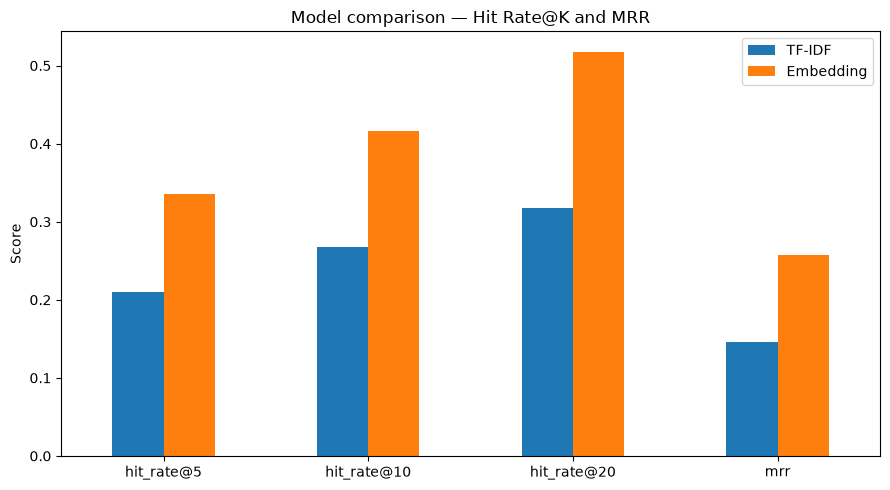

In [20]:
metrics_to_plot = [f"hit_rate@{k}" for k in EVAL_K_VALUES] + ["mrr"]
plot_df = comparison_df[metrics_to_plot]

ax = plot_df.T.plot(kind="bar", figsize=(9, 5))
ax.set_ylabel("Score")
ax.set_title("Model comparison — Hit Rate@K and MRR")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

**How to read this:** whichever model has the higher `hit_rate@K` and `mrr` is better at re-finding a recipe from a partial ingredient list. If the embedding model doesn't clearly beat TF-IDF despite its extra compute cost (model download, GPU/CPU inference time per query), the pragmatic choice for production is to ship **TF-IDF first** — it's simpler, faster, has no external model dependency, and is trivially explainable — and revisit embeddings only if real usage shows literal ingredient-name mismatches (e.g. "scallion" vs "green onion") are actually hurting results.

## 10. Export Artifacts for Backend Integration

In [ ]:
# tfidf_vectorizer = TfidfVectorizer(
#     tokenizer=custom_tokenizer,
#     preprocessor=custom_preprocessor,
#     token_pattern=None
# )

# # Use the NER column for entity-based ingredient matching
# tfidf_matrix = tfidf_vectorizer.fit_transform(df['NER'].fillna(''))


# # -------------------------------------------------------------------
# # 5. Save Artifacts
# # -------------------------------------------------------------------
# saved_to = save_artifacts(df, tfidf_vectorizer, tfidf_matrix)
# print("Artifacts saved to:", saved_to if saved_to else "SAVE FAILED — see log above")

NameError: name 'custom_tokenizer' is not defined

## 11. Summary

- **Cleaned** RecipeNLG's stringified list columns, deduplicated near-identical recipes, and filtered out ingredient-count outliers.
- **Chose content-based filtering** over collaborative filtering / supervised deep learning because RecipeNLG has no user-interaction data to train on — the honest reason, not just "TF-IDF is simple."
- **Built two models**: TF-IDF + Cosine Similarity (primary) and Sentence-Embedding Similarity (semantic alternative), both exposed through one `recommend_recipes()` function.
- **Evaluated** both with a leave-k-out self-retrieval test (Hit Rate@K, MRR, Ingredient Coverage@K), while being explicit that this metric is an optimistic proxy, not a measure of real user satisfaction.
- **Exported** the cleaned data + fitted TF-IDF vectorizer/matrix to `artifacts/` for the `ml/` Python service CookThis's backend will eventually call.

**Natural next steps once CookThis has real usage data:**
1. Log "cooked" / "saved" / thumbs-up signals from users.
2. Re-evaluate the model against *those* signals instead of the self-retrieval proxy.
3. Consider a hybrid content + collaborative model (e.g. LightFM) once there's enough interaction data to make collaborative signal meaningful.